In [19]:
import copy
import os
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint as sp_randint
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import chardet
from datetime import datetime, timedelta
import multiprocessing
from multiprocessing import Pool
import shap
import fasttreeshap
import hnswlib
from sklearn.preprocessing import StandardScaler
from scipy.spatial import KDTree
from scipy.spatial import cKDTree
from scipy.stats import pearsonr

In [2]:
#===========================================社会经济数据================================

def extract_date_from_filename_sce(filename):
    base = os.path.basename(filename)
    
    date_str = base[-14:-4]  
    #print(date_str)
    return datetime.strptime(date_str, '%Y_%m_%d')

# 文件夹路径
folder_path_sce = '/disk/r146/hcuiah/industry/industry/algorithm_sce_data'  

# 读取文件夹中的所有文件
all_files_sce = [os.path.join(folder_path_sce, f) for f in os.listdir(folder_path_sce) if os.path.isfile(os.path.join(folder_path_sce, f))and f.endswith('.csv')]
file_count = len(all_files_sce)
#print(file_count)

all_files_sce_sorted = sorted(all_files_sce, key=extract_date_from_filename_sce)
all_data_frames = []
for f in all_files_sce_sorted:
    with open(f, 'rb') as file:
        result = chardet.detect(file.read())
    encoding = result['encoding']
    df = pd.read_csv(f, encoding=encoding, index_col=0)
    all_data_frames.append(df)


# 合并所有文件到一个DataFrame中
all_data_sce = pd.concat(all_data_frames, ignore_index=True)



#print(all_data_sce)
#print(all_data_sce.shape)
target_sce = 'Carbon_Emission'  #预测变量碳排放
features_sce_with_annual = all_data_sce.drop(columns=[target_sce])  #社会经济层的attribute
features_sce = features_sce_with_annual.drop(columns='Annual_Carbon_Emission')



print(features_sce)


          Population     Nightlight   Urban_Area
0       403390.99200   81477.624710  1464.000000
1        67938.04213    3116.328627   335.235294
2       170662.07510    5827.506667   483.000000
3       362639.20990   15066.899220  1169.070588
4       214148.46560    7475.276078   748.890196
...              ...            ...          ...
797885  641063.77050  173115.041200  2599.890196
797886  315216.22850   10452.369800  1194.756863
797887  261928.68830   21331.502750   911.650980
797888  391824.01140   10179.980780   842.058824
797889  162457.53240    6951.672549   387.627451

[797890 rows x 3 columns]


In [3]:
#===========================================气候数据================================

def extract_date_from_filename_clim(filename):
    base = os.path.basename(filename)
    
    date_str = base[-12:-4]  
    #print(date_str)
    return datetime.strptime(date_str,'%Y%m%d')


# 文件夹路径
folder_path_clim = '/disk/r146/hcuiah/industry/industry/algorithm_clim_data'  

# 读取文件夹中的所有文件
all_files_clim = [os.path.join(folder_path_clim, f) for f in os.listdir(folder_path_clim) if os.path.isfile(os.path.join(folder_path_clim, f))and f.endswith('.csv')]
all_files_clim_sorted = sorted(all_files_clim, key=extract_date_from_filename_clim)

all_data_frames_clim = []
for f in all_files_clim_sorted:
    with open(f, 'rb') as file:
        result = chardet.detect(file.read())
    encoding = result['encoding']
    df = pd.read_csv(f, encoding=encoding,index_col=0)
    all_data_frames_clim.append(df)


# 合并所有文件到一个DataFrame中
all_data_clim = pd.concat(all_data_frames_clim, ignore_index=True)


#print(all_data_clim)


print(all_data_clim)
#print(features_clim)

annual_carbon = 'Annual_Carbon_Emission'

clim_without_annual = all_data_clim.drop(columns=[annual_carbon]) 
print(clim_without_annual)


         Humidity   elevation   Rainfall  Temperature  WindSpeed  \
0       86.180485  101.693060   0.024163     7.969243   2.771731   
1       79.546844   31.984680   2.048448     5.540838   7.551524   
2       81.813309   63.334271   1.481431     5.864697   7.448873   
3       90.310109  291.570718   2.584970     4.028017   5.388154   
4       89.158973  521.101918   5.037054     2.222457   6.561753   
...           ...         ...        ...          ...        ...   
797885  79.252038  212.630181  12.465162     4.856947   3.844480   
797886  86.533054  259.050886   0.820888     2.269249   3.227440   
797887  91.186793  319.617902   0.666878     1.808892   3.535056   
797888  92.727482  342.278264   1.861010     1.317798   4.521045   
797889  90.501155    9.097688   4.014644     3.722865   5.885913   

        Annual_Carbon_Emission  Carbon_Emission  
0                   399.166281         2.585238  
1                   606.903915         0.049123  
2                   490.208839   

          Population     Nightlight   Urban_Area   Humidity   elevation  \
0       403390.99200   81477.624710  1464.000000  86.180485  101.693060   
1        67938.04213    3116.328627   335.235294  79.546844   31.984680   
2       170662.07510    5827.506667   483.000000  81.813309   63.334271   
3       362639.20990   15066.899220  1169.070588  90.310109  291.570718   
4       214148.46560    7475.276078   748.890196  89.158973  521.101918   
...              ...            ...          ...        ...         ...   
797885  641063.77050  173115.041200  2599.890196  79.252038  212.630181   
797886  315216.22850   10452.369800  1194.756863  86.533054  259.050886   
797887  261928.68830   21331.502750   911.650980  91.186793  319.617902   
797888  391824.01140   10179.980780   842.058824  92.727482  342.278264   
797889  162457.53240    6951.672549   387.627451  90.501155    9.097688   

         Rainfall  Temperature  WindSpeed  Carbon_Emission  
0        0.024163     7.969243   2.771

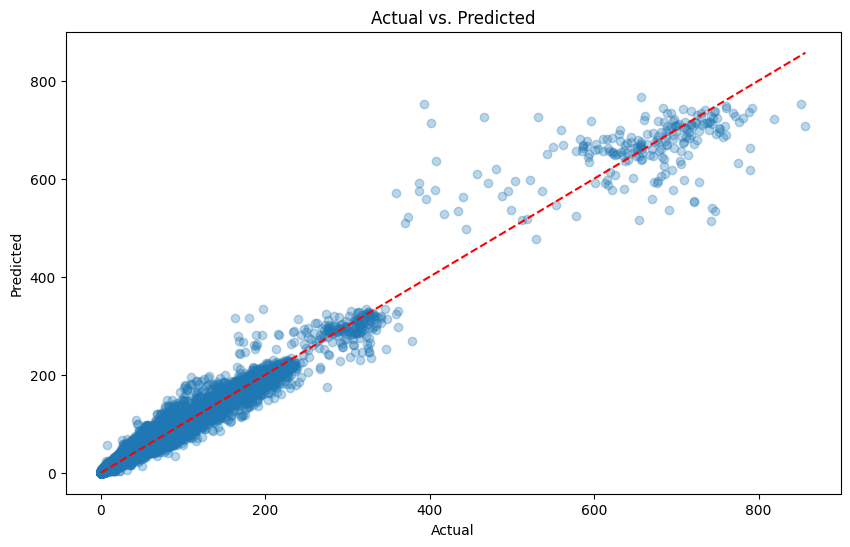

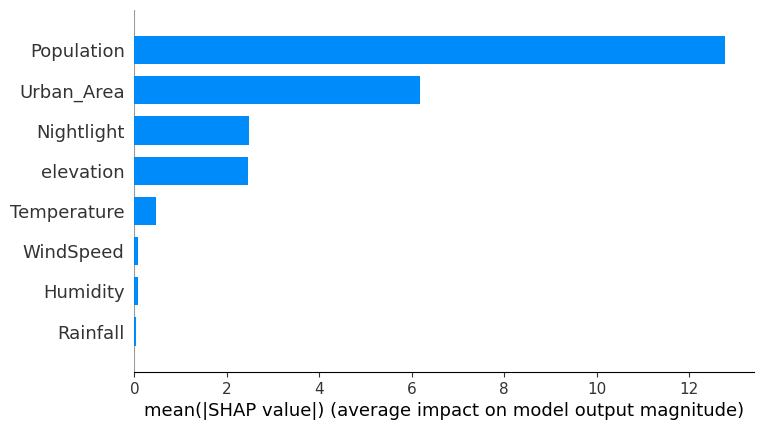

In [4]:
#================================rf+shap计算权重========================

all_data = pd.concat([features_sce, clim_without_annual], axis=1)
print(all_data)
target = 'Carbon_Emission'

features = all_data.drop(columns=[target]) 
print(features)

X_train, X_test, y_train, y_test = train_test_split(features, all_data[target], test_size=0.3, random_state=42)

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# 设置要随机搜索的超参数的分布
param_dist = {
    'n_estimators': sp_randint(100, 1000),  # 随机森林中树的数量
    'max_features': [None, 'sqrt', 'log2'],  # 查找最佳分割时要考虑的特征数量
    'max_depth': sp_randint(3, 20),  # 树的最大深度
    'min_samples_split': sp_randint(2, 11),  # 分割内部节点所需的最小样本数
    'min_samples_leaf': sp_randint(1, 11),  # 叶节点所需的最小样本数
}


n_iter_search = 15  # 要尝试的不同参数组合的数量
random_search = RandomizedSearchCV(rf, param_distributions=param_dist,
                                   n_iter=n_iter_search, cv=5, n_jobs=120)

random_search.fit(X_train, y_train)

best_params = random_search.best_params_

rf_best = RandomForestRegressor(**best_params, random_state=42, n_jobs=120)


rf_best.fit(X_train, y_train)

# 预测测试集
y_pred_train = rf_best.predict(X_train)

# 性能指标
mse_train = mean_squared_error(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

print(f'Mean Squared Error trainset: {mse_train}')
print(f'Mean Absolute Error trainset: {mae_train}')
print(f'R2 Score trainset: {r2_train}')


# 预测测试集
y_pred = rf_best.predict(X_test)

# 性能指标
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error testset: {mse}')
print(f'Mean Absolute Error testset: {mae}')
print(f'R2 Score testset: {r2}')


# 可视化预测值与实际值
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs. Predicted')
plt.show()

explainer = fasttreeshap.TreeExplainer(rf_best, algorithm='auto', n_jobs = -1)

#explainer = shap.TreeExplainer(rf_best)
shap_values = explainer.shap_values(X_test)

fasttreeshap.summary_plot(shap_values, X_test, plot_type="bar")

In [5]:
np.save('/localdisk/r146/export/hcuiah/industry/industry/shapvalues_industry/shap_values_industry', shap_values)

In [6]:
# 加载SHAP值

shap_values= np.load('/disk/r146/hcuiah/industry/industry/shapvalues_industry/shap_values_industry.npy', allow_pickle=True)

all_data = pd.concat([features_sce, clim_without_annual], axis=1)
#print(all_data)
target = 'Carbon_Emission'

features = all_data.drop(columns=[target]) 
#print(features)

X_train, X_test, y_train, y_test = train_test_split(features, all_data[target], test_size=0.3, random_state=42)



In [7]:
# 计算每个特征的平均绝对SHAP值
shap_abs_mean = np.abs(shap_values).mean(axis=0)
print(shap_abs_mean)

norm_shap_abs_mean = shap_abs_mean / shap_abs_mean.sum()
print(norm_shap_abs_mean)

# 将平均绝对SHAP值转换为DataFrame以便于排序和可视化
shap_importance = pd.DataFrame(norm_shap_abs_mean, index=X_test.columns, columns=['SHAP Importance'])

# 对特征按其平均绝对SHAP值排序
shap_importance_sorted = shap_importance.sort_values(by='SHAP Importance', ascending=False)

print(shap_importance_sorted)

[12.7764871   2.48864411  6.17940011  0.07089298  2.45138214  0.03364875
  0.46515635  0.07548431]
[0.520616   0.10140721 0.25179805 0.00288875 0.09988886 0.00137112
 0.01895418 0.00307583]
             SHAP Importance
Population          0.520616
Urban_Area          0.251798
Nightlight          0.101407
elevation           0.099889
Temperature         0.018954
WindSpeed           0.003076
Humidity            0.002889
Rainfall            0.001371


In [8]:
all_data = pd.concat([features_sce, clim_without_annual], axis=1)
print(all_data)
target = 'Carbon_Emission'

features = all_data.drop(columns=[target]) 
print(features)

          Population     Nightlight   Urban_Area   Humidity   elevation  \
0       403390.99200   81477.624710  1464.000000  86.180485  101.693060   
1        67938.04213    3116.328627   335.235294  79.546844   31.984680   
2       170662.07510    5827.506667   483.000000  81.813309   63.334271   
3       362639.20990   15066.899220  1169.070588  90.310109  291.570718   
4       214148.46560    7475.276078   748.890196  89.158973  521.101918   
...              ...            ...          ...        ...         ...   
797885  641063.77050  173115.041200  2599.890196  79.252038  212.630181   
797886  315216.22850   10452.369800  1194.756863  86.533054  259.050886   
797887  261928.68830   21331.502750   911.650980  91.186793  319.617902   
797888  391824.01140   10179.980780   842.058824  92.727482  342.278264   
797889  162457.53240    6951.672549   387.627451  90.501155    9.097688   

         Rainfall  Temperature  WindSpeed  Carbon_Emission  
0        0.024163     7.969243   2.771

In [9]:
importance = norm_shap_abs_mean
print(importance)

[0.520616   0.10140721 0.25179805 0.00288875 0.09988886 0.00137112
 0.01895418 0.00307583]


In [10]:
#=============================对于有数据的798619个城市进行归一化================
# 初始化StandardScaler
scaler = StandardScaler()

# 对特征进行Z得分归一化
features_norm = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)

# 获取每个特征的平均值和标准差，以便后续使用
features_mean_values = scaler.mean_
features_std_values = scaler.scale_

print(features_mean_values)
print(features_std_values)

print(features_norm)

[2.28238374e+06 8.70825269e+04 2.02592969e+03 6.86026312e+01
 4.16600265e+02 2.97632210e+00 1.46738738e+01 3.06129322e+00]
[3.78718609e+06 1.21836601e+05 2.80795497e+03 1.56495826e+01
 5.80325374e+02 7.00829751e+00 9.92499993e+00 1.42963254e+00]
        Population  Nightlight  Urban_Area  Humidity  elevation  Rainfall  \
0        -0.496145   -0.046003   -0.200121  1.123215  -0.542639 -0.421238   
1        -0.584721   -0.689171   -0.602109  0.699329  -0.662759 -0.132396   
2        -0.557596   -0.666918   -0.549485  0.844155  -0.608738 -0.213303   
3        -0.506905   -0.591084   -0.305154  1.387096  -0.215447 -0.055841   
4        -0.546114   -0.653394   -0.454793  1.313539   0.180074  0.294042   
...            ...         ...         ...       ...        ...       ...   
797885   -0.433388    0.706130    0.204405  0.680491  -0.351475  1.353944   
797886   -0.519427   -0.628958   -0.296006  1.145744  -0.271485 -0.307555   
797887   -0.533498   -0.539666   -0.396829  1.443116  -0.1671

In [11]:
#===============================对于有数据的798619个城市进行加权=======================


features_norm_weight = features_norm.multiply(importance, axis=1)
print(features_norm_weight)

        Population  Nightlight  Urban_Area  Humidity  elevation  Rainfall  \
0        -0.258301   -0.004665   -0.050390  0.003245  -0.054204 -0.000578   
1        -0.304415   -0.069887   -0.151610  0.002020  -0.066202 -0.000182   
2        -0.290294   -0.067630   -0.138359  0.002439  -0.060806 -0.000292   
3        -0.263903   -0.059940   -0.076837  0.004007  -0.021521 -0.000077   
4        -0.284316   -0.066259   -0.114516  0.003794   0.017987  0.000403   
...            ...         ...         ...       ...        ...       ...   
797885   -0.225629    0.071607    0.051469  0.001966  -0.035108  0.001856   
797886   -0.270422   -0.063781   -0.074534  0.003310  -0.027118 -0.000422   
797887   -0.277747   -0.054726   -0.099921  0.004169  -0.016693 -0.000452   
797888   -0.259891   -0.064008   -0.106161  0.004453  -0.012793 -0.000218   
797889   -0.291422   -0.066695   -0.146912  0.004042  -0.070142  0.000203   

        Temperature  WindSpeed  
0         -0.012804  -0.000623  
1        

In [12]:
features_norm_weight_with_carbon = features_norm_weight.copy()
features_norm_weight_with_carbon['Carbon_Emission'] = all_data['Carbon_Emission']
print(features_norm_weight_with_carbon)

        Population  Nightlight  Urban_Area  Humidity  elevation  Rainfall  \
0        -0.258301   -0.004665   -0.050390  0.003245  -0.054204 -0.000578   
1        -0.304415   -0.069887   -0.151610  0.002020  -0.066202 -0.000182   
2        -0.290294   -0.067630   -0.138359  0.002439  -0.060806 -0.000292   
3        -0.263903   -0.059940   -0.076837  0.004007  -0.021521 -0.000077   
4        -0.284316   -0.066259   -0.114516  0.003794   0.017987  0.000403   
...            ...         ...         ...       ...        ...       ...   
797885   -0.225629    0.071607    0.051469  0.001966  -0.035108  0.001856   
797886   -0.270422   -0.063781   -0.074534  0.003310  -0.027118 -0.000422   
797887   -0.277747   -0.054726   -0.099921  0.004169  -0.016693 -0.000452   
797888   -0.259891   -0.064008   -0.106161  0.004453  -0.012793 -0.000218   
797889   -0.291422   -0.066695   -0.146912  0.004042  -0.070142  0.000203   

        Temperature  WindSpeed  Carbon_Emission  
0         -0.012804  -0.0

In [13]:


# 提取 Annual_Carbon_Emission 列
annual_carbon_emission = all_data_clim['Annual_Carbon_Emission'].values.reshape(-1, 1)

# 使用 z-score 归一化
carbon_scaler = StandardScaler()
normalized_annual_carbon_emission = carbon_scaler.fit_transform(annual_carbon_emission)

annual_carbon_mean_values = carbon_scaler.mean_
annual_carbon_std_values = carbon_scaler.scale_



print(normalized_annual_carbon_emission)
# 构建 k-d 树
annual_carbon_kdtree = cKDTree(normalized_annual_carbon_emission)



[[-0.31377834]
 [-0.29360252]
 [-0.30493613]
 ...
 [-0.33783192]
 [-0.29757135]
 [-0.34441944]]


In [14]:
def normalize_and_weight(city_attributes, mean_values, std_values, weights):
    
    
    # Z得分归一化
    normalized = (city_attributes - mean_values) / std_values
    # 加权，乘以权重的根号值
    weighted = normalized * weights
    return weighted


def normalized_annual_carbon(wait_to_cal_annual_carbon, mean_values, std_values):    
    return (wait_to_cal_annual_carbon-mean_values)/std_values

In [15]:
wait_to_cal_city_list = pd.read_csv('/disk/r146/hcuiah/industry/industry/wait_to_cal_city_list_final.csv')
print(wait_to_cal_city_list)

        FID
0         0
1        12
2        14
3        18
4        21
...     ...
6228  10459
6229  10460
6230  10461
6231  10463
6232  10465

[6233 rows x 1 columns]


In [16]:


#def scotts_rule_bandwidth(distance):
#    n = len(distance)  # 样本大小
#    sigma = np.std(distance, ddof=1)  # 计算标准差，使用n-1作为除数以得到无偏估计
#    bandwidth = n**(-1/5) * sigma  # 应用Scott's Rule公式
#    return bandwidth

#def silverman_bandwidth(distance):
#    n = len(distance)
#    std_dev = np.std(distance)
#    return (4 * std_dev**5 / (3 * n))**(1/5)

# 定义一个高斯核函数，用于计算权重
def gaussian_kernel(distance):
    c = 0.56
    average_distance = np.mean(distance)
    bandwidth = c*average_distance
    #bandwidth = silverman_bandwidth(distance)
    #bandwidth = scotts_rule_bandwidth(distance)
    #print(bandwidth)
    # 计算权重
    weights = np.exp(-0.5 * (distance**2) / bandwidth**2)
    return weights


# 定义一个高斯核函数，用于计算权重
#def gaussian_kernel(distance):
    #average_distance = np.mean(distance)
    #bandwidth = average_distance
#    bandwidth = silverman_bandwidth(distance)
    #bandwidth = scotts_rule_bandwidth(distance)
    #print(bandwidth)
    # 计算权重
#    weights = np.exp(-0.5 * (distance**2) / bandwidth**2)
#    weight_sum = weights.sum()
#    if weight_sum == 0:
#        average_distance = np.mean(distance)
#        bandwidth = average_distance
#        weights = np.exp(-0.5 * (distance**2) / bandwidth**2)
        
        
#    return weights

# 归一化权重
def normalize_weights(weights):
    return weights / np.sum(weights)

#def normalize_weights(weights):
#    weight_sum = np.sum(weights)
    # 检查权重总和是否为0
#    if weight_sum > 0:
        # 如果权重总和大于0，则正常归一化
#        return weights / weight_sum
#    else:
        # 如果权重总和为0，则假设每个元素的权重相等，进行均匀分配
#        return np.ones_like(weights) / len(weights)


In [29]:


start_date = datetime(2014, 3, 1)
end_date = datetime(2014, 5, 1)
n1 = 30
n2 = 10
output_folder = "/localdisk/r146/export/hcuiah/industry/industry/output_carbon_industry"
for single_date in pd.date_range(start_date, end_date):
    results = []
    date_str = single_date.strftime("%Y_%m_%d")
    file_path_sce = f"/localdisk/r146/export/hcuiah/industry/industry/wait_to_cal_data_sce/sce_6000_data_final{date_str}.csv"
    file_path_clim = f"/localdisk/r146/export/hcuiah/industry/industry/wait_to_cal_data_clim/clim_6000_data_final{single_date.strftime('%Y%m%d')}.csv"
    data_sce = pd.read_csv(file_path_sce).drop(columns=['FID','Annual_Carbon_Emission'])
    data_clim = pd.read_csv(file_path_clim).drop(columns=['FID'])
    data_combined = pd.concat([data_sce, data_clim], axis=1)
    
    
    
    for index, row in data_combined.iterrows():
        fid = wait_to_cal_city_list.iloc[index]['FID']
        if fid != 7268:
            continue
        #取出annual carbon
        wait_to_cal_annual_carbon = row['Annual_Carbon_Emission']
        wait_to_cal_annual_carbon_after_deal = normalized_annual_carbon(wait_to_cal_annual_carbon,annual_carbon_mean_values,annual_carbon_std_values)
        
        #找到annual carbon最相似的n1个city
        
        dists, idxs = annual_carbon_kdtree.query([wait_to_cal_annual_carbon_after_deal], k=n1)
        print(dists)
        #print(idxs)
        #对应回有数据的798620个city中
        wait_to_cal_city_features_with_carbon = features_norm_weight_with_carbon.iloc[idxs[0]]
        wait_to_cal_city_features = features_norm_weight.iloc[idxs[0]].to_numpy()
        
        #建立hnsw索引
        dim = wait_to_cal_city_features.shape[1]
        num_features = wait_to_cal_city_features.shape[0]
        p = hnswlib.Index(space='l2', dim=dim)  # 使用L2距离
        p.init_index(max_elements=num_features, ef_construction=200, M=16)
        p.add_items(wait_to_cal_city_features)
        p.set_ef(50)
        
        #归一化剩下的8个attribute
        
        city_attributes = row.drop('Annual_Carbon_Emission').to_numpy()
        wait_to_cal_city_after_deal = normalize_and_weight(city_attributes,features_mean_values, features_std_values, importance)
        
        #使用hnsw找到最相似的n2个城市
        
        labels, distances = p.knn_query(wait_to_cal_city_after_deal, k=n2)
        
        if 0 in distances:  # 确保检查整个距离数组
            # 如果有距离为0的城市，则说明包含了查询的城市本身，需要将n1增加1后重新查询
            labels, distances = p.knn_query(wait_to_cal_city_after_deal, k=n2 + 1)
            # 使用提供的逻辑去除距离为0的城市
            # 由于现在已经知道确实有一个距离为0的结果，直接去掉第一个最相似的（假设是自己）
            filtered_labels = labels[:, 1:]  # 去除距离为0的城市的标签
            filtered_distances = distances[:, 1:]  # 去除距离为0的城市的距离
        else:
            # 如果没有距离为0的情况，则直接使用原始查询结果，不需要重新赋值
            # 这里不做任何操作，因为labels和distances已经是我们想要的n1个结果
            filtered_labels = labels
            filtered_distances = distances
        
        #print(filtered_labels)
        print(filtered_distances)
        # 计算高斯核权重
        carbon_weights = gaussian_kernel(filtered_distances)
        #print(carbon_weights)
        normalized_carbon_weights = normalize_weights(carbon_weights)
        normalized_carbon_weights = normalized_carbon_weights.flatten()
        #print(normalized_carbon_weights)
        # 获取相似城市的碳排放值
        similar_cities_carbon =  wait_to_cal_city_features_with_carbon['Carbon_Emission'].iloc[filtered_labels.flatten()].to_numpy()
        #print(similar_cities_carbon)
        
        # 计算加权平均碳排放值
        estimated_carbon_emission = np.dot(normalized_carbon_weights, similar_cities_carbon)
        #print(estimated_carbon_emission)
        results.append([fid, estimated_carbon_emission])
        break
    results_df = pd.DataFrame(results, columns=['FID', 'Estimated_Carbon_Emission'])
    output_csv_path = os.path.join(output_folder, f"carbon_emissions_{date_str}.csv")
    results_df.to_csv(output_csv_path, index=False)
    break

[[0.00012769 0.00012769 0.00012769 0.00012769 0.00012769 0.00012769
  0.00012769 0.00012769 0.00012769 0.00012769 0.00012769 0.00012769
  0.00012769 0.00012769 0.00012769 0.00012769 0.00012769 0.00012769
  0.00012769 0.00012769 0.00012769 0.00012769 0.00012769 0.00012769
  0.00012769 0.00012769 0.00012769 0.00012769 0.00012769 0.00012769]]
[[0.41892868 0.42132968 0.42200166 0.47044522 0.4838319  0.4947068
  0.4990266  0.5249664  0.59423566 0.63257307]]


In [16]:
start_date = datetime(2012, 1, 19)
end_date = datetime(2020, 12, 30)
n1 = 20
n2 = 10
output_folder = "/localdisk/r146/export/hcuiah/industry/industry/output_carbon_industry6"


def process_single_date(single_date):
    date_str = single_date.strftime("%Y_%m_%d")
    file_path_sce = f"/localdisk/r146/export/hcuiah/industry/industry/wait_to_cal_data_sce/sce_6000_data_final{date_str}.csv"
    file_path_clim = f"/localdisk/r146/export/hcuiah/industry/industry/wait_to_cal_data_clim/clim_6000_data_final{single_date.strftime('%Y%m%d')}.csv"
    data_sce = pd.read_csv(file_path_sce).drop(columns=['FID','Annual_Carbon_Emission'])
    data_clim = pd.read_csv(file_path_clim).drop(columns=['FID'])
    data_combined = pd.concat([data_sce, data_clim], axis=1)
    #print(data_combined)
    results = []
    for index, row in data_combined.iterrows():
        fid = wait_to_cal_city_list.iloc[index]['FID']
        
        #取出annual carbon
        wait_to_cal_annual_carbon = row['Annual_Carbon_Emission']
        wait_to_cal_annual_carbon_after_deal = normalized_annual_carbon(wait_to_cal_annual_carbon,annual_carbon_mean_values,annual_carbon_std_values)
        
        #找到annual carbon最相似的n1个city
        
        dists, idxs = annual_carbon_kdtree.query([wait_to_cal_annual_carbon_after_deal], k=n1)
        average_filtered_distance = np.mean(dists)
        #对应回有数据的798620个city中
        wait_to_cal_city_features_with_carbon = features_norm_weight_with_carbon.iloc[idxs[0]]
        wait_to_cal_city_features = features_norm_weight.iloc[idxs[0]].to_numpy()
        
        #建立hnsw索引
        dim = wait_to_cal_city_features.shape[1]
        num_features = wait_to_cal_city_features.shape[0]
        p = hnswlib.Index(space='l2', dim=dim)  # 使用L2距离
        p.init_index(max_elements=num_features, ef_construction=200, M=16)
        p.add_items(wait_to_cal_city_features)
        p.set_ef(50)
        
        #归一化剩下的8个attribute
        
        city_attributes = row.drop('Annual_Carbon_Emission').to_numpy()
        wait_to_cal_city_after_deal = normalize_and_weight(city_attributes,features_mean_values, features_std_values, importance)
        
        #使用hnsw找到最相似的n2个城市
        
        labels, distances = p.knn_query(wait_to_cal_city_after_deal, k=n2)
        
        if 0 in distances:  # 确保检查整个距离数组
            # 如果有距离为0的城市，则说明包含了查询的城市本身，需要将n1增加1后重新查询
            labels, distances = p.knn_query(wait_to_cal_city_after_deal, k=n2 + 1)
            # 使用提供的逻辑去除距离为0的城市
            # 由于现在已经知道确实有一个距离为0的结果，直接去掉第一个最相似的（假设是自己）
            filtered_labels = labels[:, 1:]  # 去除距离为0的城市的标签
            filtered_distances = distances[:, 1:]  # 去除距离为0的城市的距离
        else:
            # 如果没有距离为0的情况，则直接使用原始查询结果，不需要重新赋值
            # 这里不做任何操作，因为labels和distances已经是我们想要的n1个结果
            filtered_labels = labels
            filtered_distances = distances
        
        #print(filtered_labels)
        #print(filtered_distances)
        # 计算高斯核权重
        carbon_weights = gaussian_kernel(filtered_distances)
        #print(carbon_weights)
        normalized_carbon_weights = normalize_weights(carbon_weights)
        normalized_carbon_weights = normalized_carbon_weights.flatten()
        #print(normalized_carbon_weights)
        # 获取相似城市的碳排放值
        similar_cities_carbon =  wait_to_cal_city_features_with_carbon['Carbon_Emission'].iloc[filtered_labels.flatten()].to_numpy()
        #print(similar_cities_carbon)
        
        # 计算加权平均碳排放值
        estimated_carbon_emission = np.dot(normalized_carbon_weights, similar_cities_carbon)

        results.append([fid, estimated_carbon_emission,average_filtered_distance])
        #break
    results_df = pd.DataFrame(results, columns=['FID', 'Estimated_Carbon_Emission', 'Average_edgar_Distance'])
    output_csv_path = os.path.join(output_folder, f"carbon_emissions_{date_str}.csv")
    results_df.to_csv(output_csv_path, index=False)
        
    
date_range = pd.date_range(start_date, end_date)

# 使用 Pool 来并行处理日期
with Pool(processes=120) as pool:  # 可以根据你的系统情况调整进程数
    pool.map(process_single_date, date_range)

In [17]:
start_date = datetime(2012, 1, 19)
end_date = datetime(2020, 12, 30)
n1 = 730
n2 = 80
output_folder = "/localdisk/r146/export/hcuiah/industry/industry/final_carbon_output_n1_730_n2_80"


def process_single_date(single_date):
    date_str = single_date.strftime("%Y_%m_%d")
    file_path_sce = f"/disk/r146/hcuiah/industry/industry/wait_to_cal_data_sce_with_8_annual_carbon/sce_6000_data_final{date_str}.csv"
    file_path_clim = f"/disk/r146/hcuiah/industry/industry/wait_to_cal_data_clim/clim_6000_data_final{single_date.strftime('%Y%m%d')}.csv"
    data_sce = pd.read_csv(file_path_sce).drop(columns=['FID','Annual_Carbon_Emission'])
    data_clim = pd.read_csv(file_path_clim).drop(columns=['FID'])
    data_combined = pd.concat([data_sce, data_clim], axis=1)
    #print(data_combined)
    results = []
    for index, row in data_combined.iterrows():
        fid = wait_to_cal_city_list.iloc[index]['FID']
        
        #取出annual carbon
        wait_to_cal_annual_carbon = row['8_Year_Avg_Carbon_Emission']
        wait_to_cal_annual_carbon_after_deal = normalized_annual_carbon(wait_to_cal_annual_carbon,annual_carbon_mean_values,annual_carbon_std_values)
        
        #找到annual carbon最相似的n1个city
        
        dists, idxs = annual_carbon_kdtree.query([wait_to_cal_annual_carbon_after_deal], k=n1)
        
        #对应回有数据的798620个city中
        wait_to_cal_city_features_with_carbon = features_norm_weight_with_carbon.iloc[idxs[0]]
        wait_to_cal_city_features = features_norm_weight.iloc[idxs[0]].to_numpy()
        
        #建立hnsw索引
        dim = wait_to_cal_city_features.shape[1]
        num_features = wait_to_cal_city_features.shape[0]
        p = hnswlib.Index(space='l2', dim=dim)  # 使用L2距离
        p.init_index(max_elements=num_features, ef_construction=200, M=16)
        p.add_items(wait_to_cal_city_features)
        p.set_ef(50)
        
        #归一化剩下的8个attribute
        
        city_attributes = row.drop(['8_Year_Avg_Carbon_Emission','Annual_Carbon_Emission']).to_numpy()
        wait_to_cal_city_after_deal = normalize_and_weight(city_attributes,features_mean_values, features_std_values, importance)
        
        #使用hnsw找到最相似的n2个城市
        
        labels, distances = p.knn_query(wait_to_cal_city_after_deal, k=n2)
        
        if 0 in distances:  # 确保检查整个距离数组
            # 如果有距离为0的城市，则说明包含了查询的城市本身，需要将n1增加1后重新查询
            labels, distances = p.knn_query(wait_to_cal_city_after_deal, k=n2 + 1)
            # 使用提供的逻辑去除距离为0的城市
            # 由于现在已经知道确实有一个距离为0的结果，直接去掉第一个最相似的（假设是自己）
            filtered_labels = labels[:, 1:]  # 去除距离为0的城市的标签
            filtered_distances = distances[:, 1:]  # 去除距离为0的城市的距离
        else:
            # 如果没有距离为0的情况，则直接使用原始查询结果，不需要重新赋值
            # 这里不做任何操作，因为labels和distances已经是我们想要的n1个结果
            filtered_labels = labels
            filtered_distances = distances
        
        #print(filtered_labels)
        #print(filtered_distances)
        # 计算高斯核权重
        carbon_weights = gaussian_kernel(filtered_distances)
        #print(carbon_weights)
        normalized_carbon_weights = normalize_weights(carbon_weights)
        normalized_carbon_weights = normalized_carbon_weights.flatten()
        #print(normalized_carbon_weights)
        # 获取相似城市的碳排放值
        similar_cities_carbon =  wait_to_cal_city_features_with_carbon['Carbon_Emission'].iloc[filtered_labels.flatten()].to_numpy()
        #print(similar_cities_carbon)
        
        # 计算加权平均碳排放值
        estimated_carbon_emission = np.dot(normalized_carbon_weights, similar_cities_carbon)

        results.append([fid, estimated_carbon_emission])
        #break
    results_df = pd.DataFrame(results, columns=['FID', 'Estimated_Carbon_Emission'])
    output_csv_path = os.path.join(output_folder, f"carbon_emissions_{date_str}.csv")
    results_df.to_csv(output_csv_path, index=False)
        
    
date_range = pd.date_range(start_date, end_date)

# 使用 Pool 来并行处理日期
with Pool(processes=128) as pool:  # 可以根据你的系统情况调整进程数
    pool.map(process_single_date, date_range)

In [15]:


start_date = datetime(2012, 1, 19)
end_date = datetime(2020, 12, 30)
n1 = 730
output_base_folder = "/disk/r146/hcuiah/industry/industry/new_carbon_output3"

def process_single_date(single_date, n2, output_folder):
    date_str = single_date.strftime("%Y_%m_%d")
    file_path_sce = f"/disk/r146/hcuiah/industry/industry/wait_to_cal_data_sce_with_8_annual_carbon/sce_6000_data_final{date_str}.csv"
    file_path_clim = f"/disk/r146/hcuiah/industry/industry/wait_to_cal_data_clim/clim_6000_data_final{single_date.strftime('%Y%m%d')}.csv"
    data_sce = pd.read_csv(file_path_sce).drop(columns=['FID','Annual_Carbon_Emission'])
    data_clim = pd.read_csv(file_path_clim).drop(columns=['FID'])
    data_combined = pd.concat([data_sce, data_clim], axis=1)
    #print(data_combined)
    results = []
    for index, row in data_combined.iterrows():
        fid = wait_to_cal_city_list.iloc[index]['FID']
        
        #取出annual carbon
        wait_to_cal_annual_carbon = row['8_Year_Avg_Carbon_Emission']
        wait_to_cal_annual_carbon_after_deal = normalized_annual_carbon(wait_to_cal_annual_carbon,annual_carbon_mean_values,annual_carbon_std_values)
        
        #找到annual carbon最相似的n1个city
        
        dists, idxs = annual_carbon_kdtree.query([wait_to_cal_annual_carbon_after_deal], k=n1)
        
        #对应回有数据的798620个city中
        wait_to_cal_city_features_with_carbon = features_norm_weight_with_carbon.iloc[idxs[0]]
        wait_to_cal_city_features = features_norm_weight.iloc[idxs[0]].to_numpy()
        
        #建立hnsw索引
        dim = wait_to_cal_city_features.shape[1]
        num_features = wait_to_cal_city_features.shape[0]
        p = hnswlib.Index(space='l2', dim=dim)  # 使用L2距离
        p.init_index(max_elements=num_features, ef_construction=200, M=16)
        p.add_items(wait_to_cal_city_features)
        p.set_ef(50)
        
        #归一化剩下的8个attribute
        
        city_attributes = row.drop(['8_Year_Avg_Carbon_Emission','Annual_Carbon_Emission']).to_numpy()
        wait_to_cal_city_after_deal = normalize_and_weight(city_attributes,features_mean_values, features_std_values, importance)
        
        #使用hnsw找到最相似的n2个城市
        
        labels, distances = p.knn_query(wait_to_cal_city_after_deal, k=n2)
        
        if 0 in distances:  # 确保检查整个距离数组
            # 如果有距离为0的城市，则说明包含了查询的城市本身，需要将n1增加1后重新查询
            labels, distances = p.knn_query(wait_to_cal_city_after_deal, k=n2 + 1)
            # 使用提供的逻辑去除距离为0的城市
            # 由于现在已经知道确实有一个距离为0的结果，直接去掉第一个最相似的（假设是自己）
            filtered_labels = labels[:, 1:]  # 去除距离为0的城市的标签
            filtered_distances = distances[:, 1:]  # 去除距离为0的城市的距离
        else:
            # 如果没有距离为0的情况，则直接使用原始查询结果，不需要重新赋值
            # 这里不做任何操作，因为labels和distances已经是我们想要的n1个结果
            filtered_labels = labels
            filtered_distances = distances
        
        #print(filtered_labels)
        #print(filtered_distances)
        # 计算高斯核权重
        carbon_weights = gaussian_kernel(filtered_distances)
        #print(carbon_weights)
        normalized_carbon_weights = normalize_weights(carbon_weights)
        normalized_carbon_weights = normalized_carbon_weights.flatten()
        #print(normalized_carbon_weights)
        # 获取相似城市的碳排放值
        similar_cities_carbon =  wait_to_cal_city_features_with_carbon['Carbon_Emission'].iloc[filtered_labels.flatten()].to_numpy()
        #print(similar_cities_carbon)
        
        # 计算加权平均碳排放值
        estimated_carbon_emission = np.dot(normalized_carbon_weights, similar_cities_carbon)

        results.append([fid, estimated_carbon_emission])
        #break
    results_df = pd.DataFrame(results, columns=['FID', 'Estimated_Carbon_Emission'])
    output_csv_path = os.path.join(output_folder, f"carbon_emissions_{date_str}.csv")
    results_df.to_csv(output_csv_path, index=False)

date_range = pd.date_range(start_date, end_date)

# 遍历n2的值并处理日期
for n2 in range(20, 101, 10):
    output_folder = f"{output_base_folder}_n2_{n2}"
    os.makedirs(output_folder, exist_ok=True)
    
    # 使用 Pool 来并行处理日期
    with Pool(processes=120) as pool:  # 可以根据你的系统情况调整进程数
        pool.starmap(process_single_date, [(single_date, n2, output_folder) for single_date in date_range])


In [22]:
from scipy.stats import pearsonr

def extract_date_from_filename(filename):
    base = os.path.basename(filename)
    date_str = base[-14:-4]  # 提取日期字符串
    return datetime.strptime(date_str, '%Y_%m_%d')

def read_and_merge_daily_data(real_emissions_folder, predicted_emissions_folder, start_date, end_date):
    date_range = pd.date_range(start_date, end_date)
    all_data_frames = []
    
    for single_date in date_range:
        date_str = single_date.strftime('%Y_%m_%d')
        real_emissions_file = os.path.join(real_emissions_folder, f'sce_industry_data_final{date_str}.csv')
        predicted_emissions_file = os.path.join(predicted_emissions_folder, f'carbon_emissions_{date_str}.csv')
        
        if os.path.exists(real_emissions_file) and os.path.exists(predicted_emissions_file):
            real_emissions_df = pd.read_csv(real_emissions_file)
            predicted_emissions_df = pd.read_csv(predicted_emissions_file)
            # 确保预测数据文件中的列名与真实数据文件中的列名匹配
            predicted_emissions_df.rename(columns={'Estimated_Carbon_Emission': 'Carbon_Emission'}, inplace=True)
            
            # 使用FID进行匹配
            merged_df = pd.merge(real_emissions_df, predicted_emissions_df[['FID', 'Carbon_Emission']], on='FID', suffixes=('_real', '_predicted'))
            all_data_frames.append(merged_df)
    
    # 合并所有天的数据
    all_data_combined = pd.concat(all_data_frames, ignore_index=True)
    #print(all_data_combined)
    return all_data_combined

def calculate_metrics(all_data_combined):
    mse = mean_squared_error(all_data_combined['Carbon_Emission_real'], all_data_combined['Carbon_Emission_predicted'])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(all_data_combined['Carbon_Emission_real'], all_data_combined['Carbon_Emission_predicted'])
    r2 = r2_score(all_data_combined['Carbon_Emission_real'], all_data_combined['Carbon_Emission_predicted'])
    n = all_data_combined.shape[0]
    rss = mse * n
    
    # 计算AIC
    k = 2  # 假设模型参数数量为2
    aic = n * np.log(rss / n) + 2 * k
    pcc, _ = pearsonr(all_data_combined['Carbon_Emission_real'], all_data_combined['Carbon_Emission_predicted'])
    return mse, rmse, mae, r2, rss, aic,pcc

# 设置起始和结束日期
start_date = datetime(2019, 1, 1)
end_date = datetime(2020, 12, 30)

# 文件夹路径，替换为你的实际路径
real_emissions_folder = '/disk/r146/hcuiah/industry/industry/algorithm_sce_data'
predicted_emissions_folder = '/localdisk/r146/export/hcuiah/industry/industry_delete_some_city/final_carbon_n1_730_n2_80_delete_400km'

# 读取、合并数据，并计算指标
all_data_combined = read_and_merge_daily_data(real_emissions_folder, predicted_emissions_folder, start_date, end_date)
mse, rmse, mae, r2, rss, aic,pcc = calculate_metrics(all_data_combined)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
#print(f"R^2: {r2}")
print(f"RSS: {rss}")
print(f"AIC: {aic}")
print(f"PCC: {pcc}")
print(f"R^2: {np.square(pcc)}")

MSE: 319.9756336216054
RMSE: 17.887862746052292
MAE: 8.759515035842712
RSS: 234049376.9688595
AIC: 4219244.376490369
PCC: 0.8443864968136073
R^2: 0.7129885560011561


In [18]:
#===========================================社会经济数据================================

def extract_date_from_filename_sce(filename):
    base = os.path.basename(filename)
    
    date_str = base[-14:-4]  
    #print(date_str)
    return datetime.strptime(date_str, '%Y_%m_%d')

# 文件夹路径
folder_path_sce = '/localdisk/r148/export/hcuiah/residential/algorithm_sce_data'  

# 读取文件夹中的所有文件
all_files_sce = [os.path.join(folder_path_sce, f) for f in os.listdir(folder_path_sce) if os.path.isfile(os.path.join(folder_path_sce, f))and f.endswith('.csv')]
file_count = len(all_files_sce)
#print(file_count)

all_files_sce_sorted = sorted(all_files_sce, key=extract_date_from_filename_sce)
all_data_frames = []
for f in all_files_sce_sorted:
    with open(f, 'rb') as file:
        result = chardet.detect(file.read())
    encoding = result['encoding']
    df = pd.read_csv(f, encoding=encoding)
    df['source_file'] = os.path.basename(f)
    all_data_frames.append(df)


# 合并所有文件到一个DataFrame中
all_data_sce = pd.concat(all_data_frames, ignore_index=True)


# 您感兴趣的行的索引
rows_of_interest = idxs.flatten()
selected_rows = all_data_sce.iloc[rows_of_interest]
selected_rows = all_data_sce.iloc[rows_of_interest]
# 打印出感兴趣的行对应的fid
print(selected_rows[['FID', 'source_file']])



          FID                               source_file
54864   10455  sce_residential_data_final2019_02_20.csv
51582   10455  sce_residential_data_final2019_02_17.csv
228810  10455  sce_residential_data_final2019_07_29.csv
163170  10455  sce_residential_data_final2019_05_30.csv
366654  10455  sce_residential_data_final2019_12_02.csv
306484  10455  sce_residential_data_final2019_10_08.csv
87684   10455  sce_residential_data_final2019_03_22.csv
27514   10455  sce_residential_data_final2019_01_26.csv
270382  10455  sce_residential_data_final2019_09_05.csv
215682  10455  sce_residential_data_final2019_07_17.csv
294450  10455  sce_residential_data_final2019_09_27.csv
140196  10455  sce_residential_data_final2019_05_09.csv
50488   10455  sce_residential_data_final2019_02_16.csv
52676   10455  sce_residential_data_final2019_02_18.csv
262724  10455  sce_residential_data_final2019_08_29.csv
35172   10455  sce_residential_data_final2019_02_02.csv
104094  10455  sce_residential_data_final2019_04